# 🚗 Car Price Prediction Using Machine Learning
---
**Objective:** Build a regression model to predict car prices using features like brand, mileage, engine power, and fuel type.  
**Dataset:** 19,237 records · 17 features  
**Tools:** Pandas · Scikit-learn · Matplotlib · Seaborn  

> **Workflow:** Data Loading → EDA → Preprocessing → Feature Engineering → Modelling → Evaluation → Insights


## 1. 📦 Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Plotting style
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'sans-serif'
sns.set_palette('husl')

print("✅ Libraries imported successfully")

✅ Libraries imported successfully


## 2. 📂 Load Dataset

In [3]:
df = pd.read_csv('car_price_prediction.csv')

print(f"Shape     : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Memory    : {df.memory_usage(deep=True).sum() / 1e6:.2f} MB")
print()
df.head()

Shape     : 19,237 rows × 18 columns
Memory    : 14.48 MB



,ID,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
0,45654403,13328,1399,LEXUS,RX 450,2010,Jeep,Yes,Hybrid,3.5,186005 km,6.0,Automatic,4x4,04-May,Left wheel,Silver,12
1,44731507,16621,1018,CHEVROLET,Equinox,2011,Jeep,No,Petrol,3,192000 km,6.0,Tiptronic,4x4,04-May,Left wheel,Black,8
2,45774419,8467,-,HONDA,FIT,2006,Hatchback,No,Petrol,1.3,200000 km,4.0,Variator,Front,04-May,Right-hand drive,Black,2
3,45769185,3607,862,FORD,Escape,2011,Jeep,Yes,Hybrid,2.5,168966 km,4.0,Automatic,4x4,04-May,Left wheel,White,0
4,45809263,11726,446,HONDA,FIT,2014,Hatchback,Yes,Petrol,1.3,91901 km,4.0,Automatic,Front,04-May,Left wheel,Silver,4


In [4]:
# Overview of dtypes and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19237 entries, 0 to 19236
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                19237 non-null  int64  
 1   Price             19237 non-null  int64  
 2   Levy              19237 non-null  object 
 3   Manufacturer      19237 non-null  object 
 4   Model             19237 non-null  object 
 5   Prod. year        19237 non-null  int64  
 6   Category          19237 non-null  object 
 7   Leather interior  19237 non-null  object 
 8   Fuel type         19237 non-null  object 
 9   Engine volume     19237 non-null  object 
 10  Mileage           19237 non-null  object 
 11  Cylinders         19237 non-null  float64
 12  Gear box type     19237 non-null  object 
 13  Drive wheels      19237 non-null  object 
 14  Doors             19237 non-null  object 
 15  Wheel             19237 non-null  object 
 16  Color             19237 non-null  object

In [5]:
# Statistical summary of numeric columns
df.describe().round(2)

,ID,Price,Prod. year,Cylinders,Airbags
count,19237.00,19237.00,19237.00,19237.00,19237.00
mean,45576535.89,18555.93,2010.91,4.58,6.58
std,936591.42,190581.27,5.67,1.20,4.32
min,20746880.00,1.00,1939.00,1.00,0.00
25%,45698374.00,5331.00,2009.00,4.00,4.00
50%,45772308.00,13172.00,2012.00,4.00,6.00
75%,45802036.00,22075.00,2015.00,4.00,12.00
max,45816654.00,26307500.00,2020.00,16.00,16.00


## 3. 🔍 Exploratory Data Analysis (EDA)

In [6]:
# Check for missing values and special placeholders
print("=== Null Counts ===")
print(df.isnull().sum())
print()
print("=== Levy unique sample (first 10) ===")
print(df['Levy'].unique()[:10])
print()
print("=== Mileage sample ===")
print(df['Mileage'].head(5).tolist())
print()
print("=== Doors unique values ===")
print(df['Doors'].unique())

=== Null Counts ===
ID                  0
Price               0
Levy                0
Manufacturer        0
Model               0
Prod. year          0
Category            0
Leather interior    0
Fuel type           0
Engine volume       0
Mileage             0
Cylinders           0
Gear box type       0
Drive wheels        0
Doors               0
Wheel               0
Color               0
Airbags             0
dtype: int64

=== Levy unique sample (first 10) ===
['1399' '1018' '-' '862' '446' '891' '761' '751' '394' '1053']

=== Mileage sample ===
['186005 km', '192000 km', '200000 km', '168966 km', '91901 km']

=== Doors unique values ===
['04-May' '02-Mar' '>5']


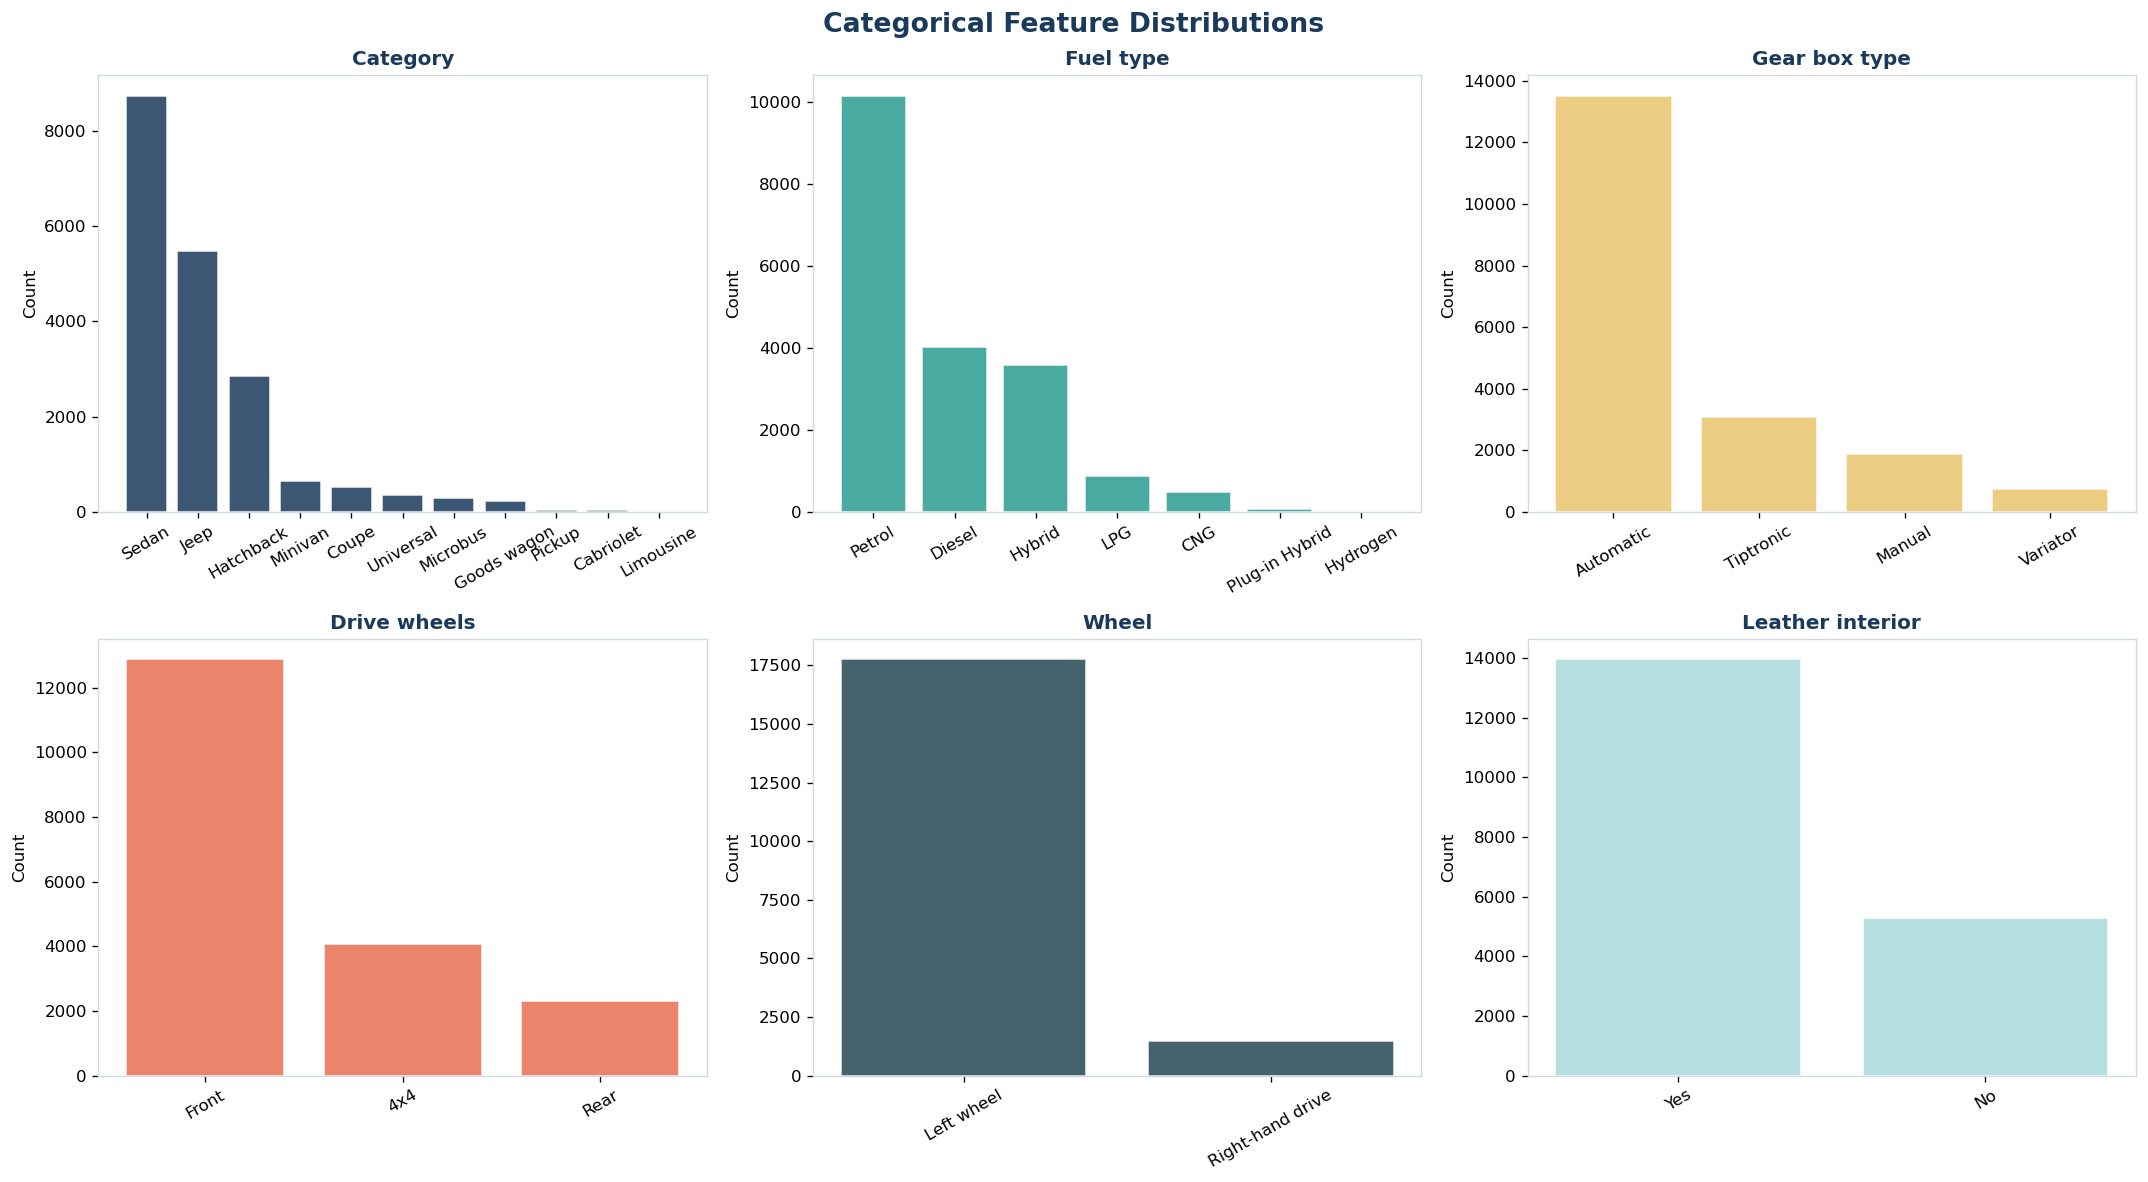

In [7]:
# Distribution of categorical features
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Categorical Feature Distributions', fontsize=16, fontweight='bold', color='#1a3a5c')

cat_features = ['Category', 'Fuel type', 'Gear box type', 'Drive wheels', 'Wheel', 'Leather interior']
colors = ['#1a3a5c', '#2a9d8f', '#e9c46a', '#e76f51', '#264653', '#a8dadc']

for ax, feat, col in zip(axes.flatten(), cat_features, colors):
    counts = df[feat].value_counts()
    ax.bar(counts.index, counts.values, color=col, edgecolor='white', alpha=0.85)
    ax.set_title(feat, fontsize=12, fontweight='bold', color='#1a3a5c')
    ax.tick_params(axis='x', rotation=30)
    ax.set_ylabel('Count')
    for spine in ax.spines.values(): spine.set_color('#d0d8e4')

plt.tight_layout()
plt.show()

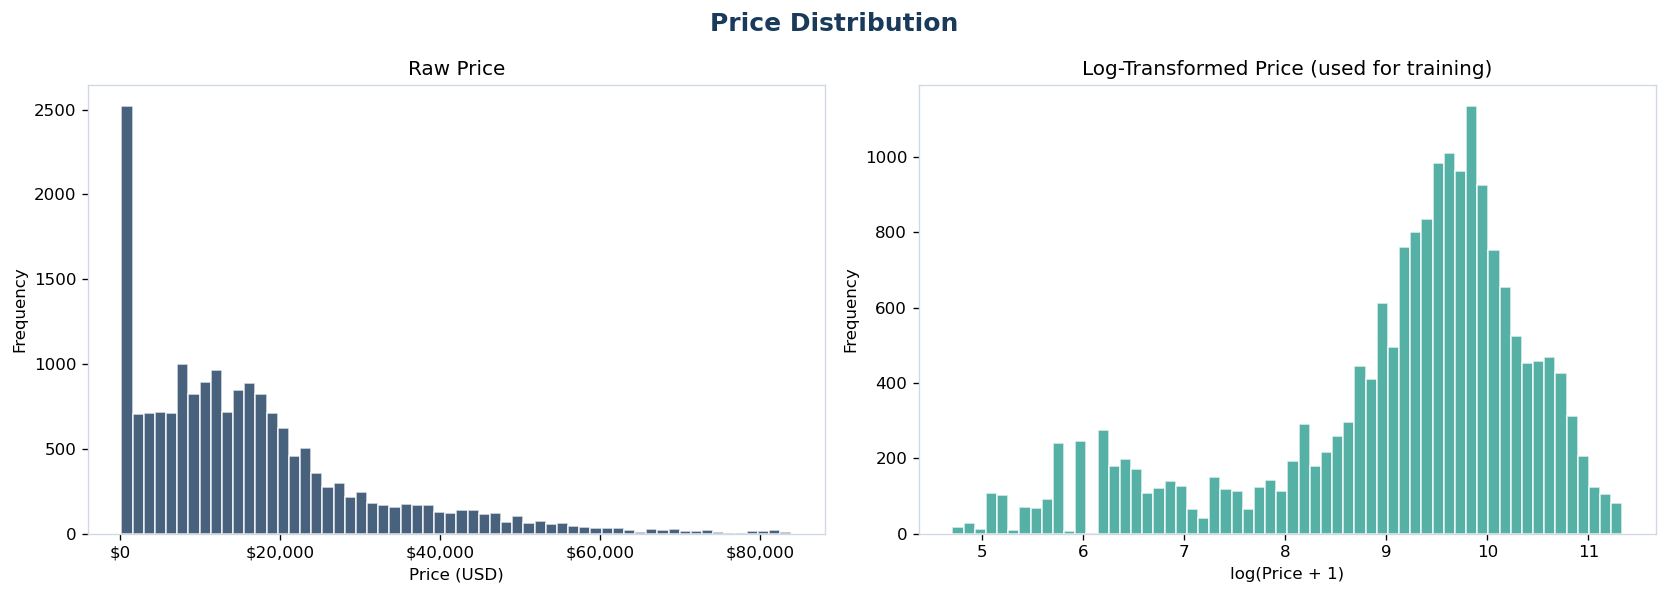

Price range: $110 → $83,891
Median price: $13,172


In [8]:
# Price distribution (raw vs log-transformed)
df_plot = df.copy()
df_plot['Price'] = pd.to_numeric(df_plot['Price'], errors='coerce')
df_plot = df_plot[(df_plot['Price'] > 100) & (df_plot['Price'] < df_plot['Price'].quantile(0.99))]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Price Distribution', fontsize=15, fontweight='bold', color='#1a3a5c')

ax1.hist(df_plot['Price'], bins=60, color='#1a3a5c', alpha=0.8, edgecolor='white')
ax1.set_title('Raw Price', fontsize=12)
ax1.set_xlabel('Price (USD)')
ax1.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

ax2.hist(np.log1p(df_plot['Price']), bins=60, color='#2a9d8f', alpha=0.8, edgecolor='white')
ax2.set_title('Log-Transformed Price (used for training)', fontsize=12)
ax2.set_xlabel('log(Price + 1)')

for ax in [ax1, ax2]:
    ax.set_ylabel('Frequency')
    for spine in ax.spines.values(): spine.set_color('#d0d8e4')

plt.tight_layout()
plt.show()
print(f"Price range: ${df_plot['Price'].min():,.0f} → ${df_plot['Price'].max():,.0f}")
print(f"Median price: ${df_plot['Price'].median():,.0f}")

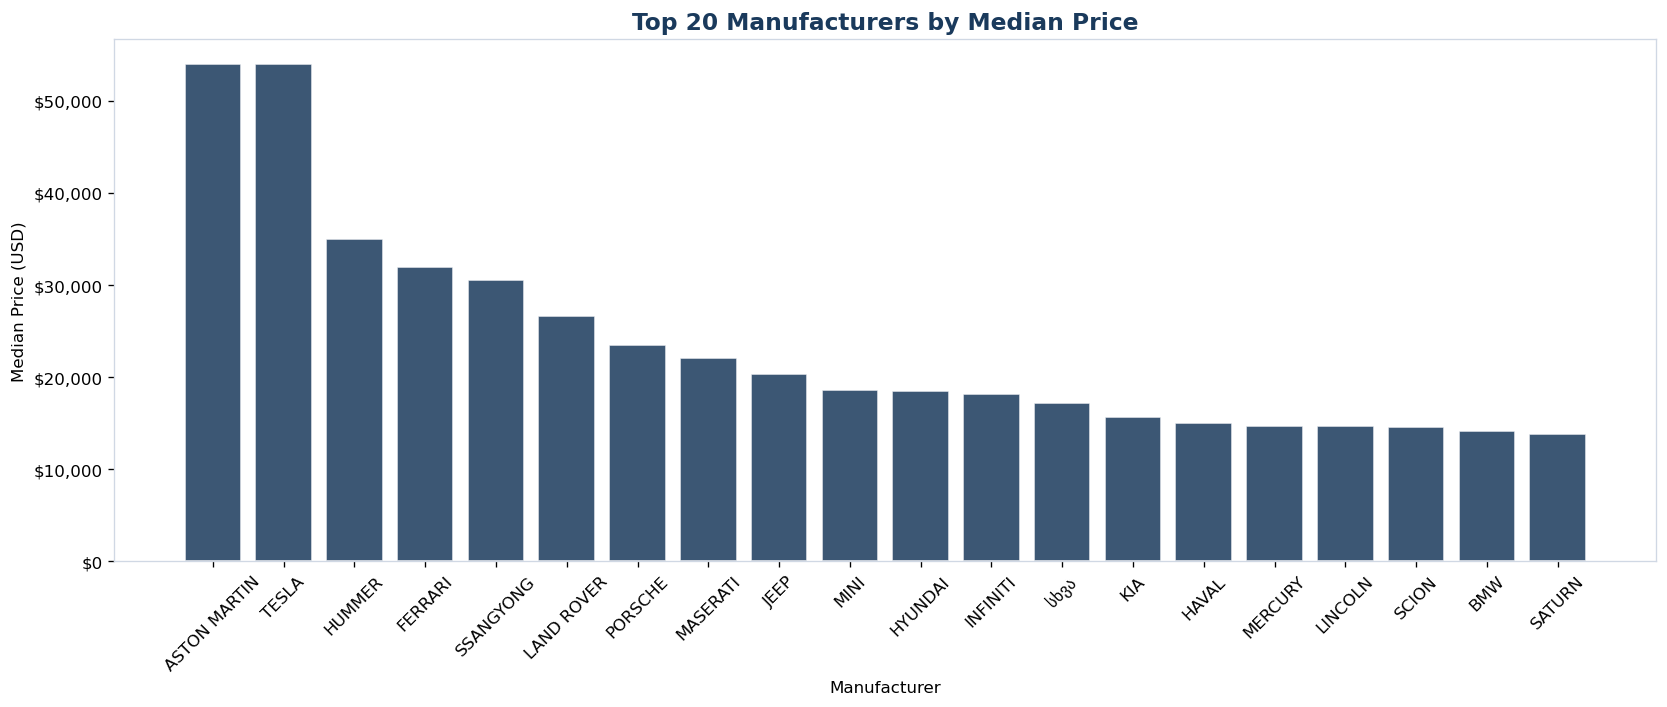

In [9]:
# Avg price by manufacturer (top 20)
df_plot['Manufacturer'] = df['Manufacturer']
top_brands = (df_plot.groupby('Manufacturer')['Price']
              .median().sort_values(ascending=False).head(20))

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.bar(top_brands.index, top_brands.values, color='#1a3a5c', edgecolor='white', alpha=0.85)
ax.set_title('Top 20 Manufacturers by Median Price', fontsize=14, fontweight='bold', color='#1a3a5c')
ax.set_xlabel('Manufacturer')
ax.set_ylabel('Median Price (USD)')
ax.tick_params(axis='x', rotation=45)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
for spine in ax.spines.values(): spine.set_color('#d0d8e4')
plt.tight_layout()
plt.show()

## 4. 🧹 Data Preprocessing

In [10]:
df = pd.read_csv('car_price_prediction.csv')
df = df.drop(columns=['ID'])

# ── Price ──────────────────────────────────────────
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')
df = df[df['Price'] < df['Price'].quantile(0.99)]   # remove top 1% outliers
df = df[df['Price'] > 100]                           # remove junk prices

# ── Levy (tax): replace '-' with 0 ─────────────────
df['Levy'] = df['Levy'].replace('-', '0').astype(float)

# ── Mileage: strip ' km' and convert ───────────────
df['Mileage'] = (df['Mileage']
                 .str.replace(' km', '', regex=False)
                 .str.replace(',', '', regex=False)
                 .astype(float))

# ── Engine volume: coerce to numeric ───────────────
df['Engine volume'] = pd.to_numeric(df['Engine volume'], errors='coerce')

# ── Doors: '04-May' style → integer ────────────────
def fix_doors(val):
    try:
        return int(str(val).split('-')[0])
    except:
        return np.nan

df['Doors'] = df['Doors'].apply(fix_doors)

# ── Leather interior: binary ────────────────────────
df['Leather_Bin'] = (df['Leather interior'] == 'Yes').astype(int)
df = df.drop(columns=['Leather interior'])

# ── Drop remaining NaNs ─────────────────────────────
df = df.dropna()

print(f"✅ Clean dataset: {df.shape[0]:,} rows × {df.shape[1]} columns")
print()
print("Sample after cleaning:")
df.head(3)

✅ Clean dataset: 16,754 rows × 17 columns

Sample after cleaning:


,Price,Levy,Manufacturer,Model,Prod. year,Category,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags,Leather_Bin
0,13328,1399.0,LEXUS,RX 450,2010,Jeep,Hybrid,3.5,186005.0,6.0,Automatic,4x4,4.0,Left wheel,Silver,12,1
1,16621,1018.0,CHEVROLET,Equinox,2011,Jeep,Petrol,3.0,192000.0,6.0,Tiptronic,4x4,4.0,Left wheel,Black,8,0
2,8467,0.0,HONDA,FIT,2006,Hatchback,Petrol,1.3,200000.0,4.0,Variator,Front,4.0,Right-hand drive,Black,2,0


## 5. ⚙️ Feature Engineering

In [11]:
# Car Age (proxy for depreciation)
df['Car_Age'] = 2024 - df['Prod. year']
df = df.drop(columns=['Prod. year'])

# Brand Value — mean price per manufacturer (market positioning signal)
brand_avg = df.groupby('Manufacturer')['Price'].mean()
df['Brand_Value'] = df['Manufacturer'].map(brand_avg)

# Mileage per Year — wear-and-tear normalised by age
df['Mileage_Per_Year'] = df['Mileage'] / (df['Car_Age'] + 1)

print("✅ Engineered features: Car_Age, Brand_Value, Mileage_Per_Year")
print()
df[['Car_Age', 'Brand_Value', 'Mileage_Per_Year']].describe().round(2)

✅ Engineered features: Car_Age, Brand_Value, Mileage_Per_Year



,Car_Age,Brand_Value,Mileage_Per_Year
count,16754.00,16754.00,1.675400e+04
mean,12.91,15638.81,6.264488e+04
std,5.61,5155.55,1.924189e+06
min,4.00,178.50,0.000000e+00
25%,9.00,12713.79,6.056520e+03
50%,12.00,14092.17,9.416670e+03
75%,14.00,22112.24,1.330864e+04
max,85.00,54000.00,1.263226e+08


## 6. 🔢 Encode Categorical Features

In [12]:
cat_cols = ['Manufacturer', 'Model', 'Category', 'Fuel type',
            'Gear box type', 'Drive wheels', 'Wheel', 'Color']

le = LabelEncoder()
for col in cat_cols:
    df[col + '_enc'] = le.fit_transform(df[col].astype(str))

df = df.drop(columns=cat_cols)

print(f"✅ Encoded {len(cat_cols)} categorical columns")
print(f"Final feature set: {df.shape[1] - 1} features + 1 target")
print()
print("Columns:", list(df.columns))

✅ Encoded 8 categorical columns
Final feature set: 18 features + 1 target

Columns: ['Price', 'Levy', 'Engine volume', 'Mileage', 'Cylinders', 'Doors', 'Airbags', 'Leather_Bin', 'Car_Age', 'Brand_Value', 'Mileage_Per_Year', 'Manufacturer_enc', 'Model_enc', 'Category_enc', 'Fuel type_enc', 'Gear box type_enc', 'Drive wheels_enc', 'Wheel_enc', 'Color_enc']


## 7. 📊 Correlation Heatmap

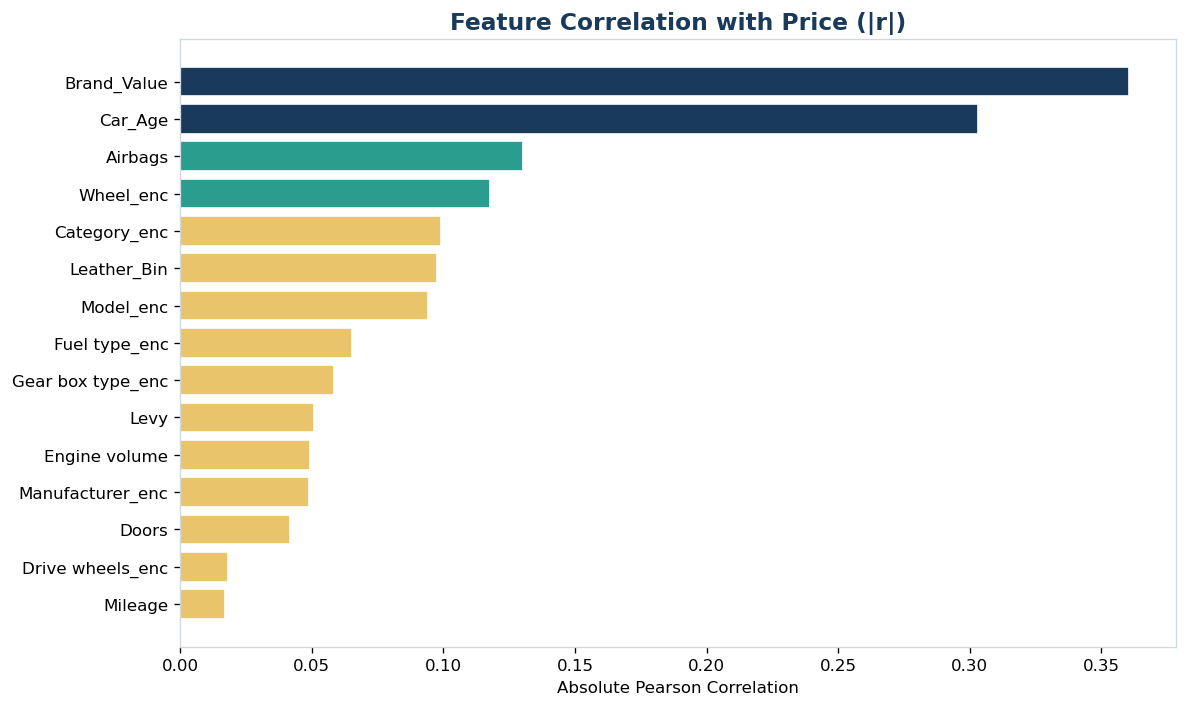

In [13]:
# Correlation with Price (top 15 features)
corr = df.corr()['Price'].drop('Price').abs().sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
colors_bar = ['#1a3a5c' if v > 0.3 else '#2a9d8f' if v > 0.1 else '#e9c46a' for v in corr.values]
ax.barh(corr.index[::-1], corr.values[::-1], color=colors_bar[::-1], edgecolor='white')
ax.set_title('Feature Correlation with Price (|r|)', fontsize=14, fontweight='bold', color='#1a3a5c')
ax.set_xlabel('Absolute Pearson Correlation')
for spine in ax.spines.values(): spine.set_color('#d0d8e4')
plt.tight_layout()
plt.show()

## 8. ✂️ Train / Test Split & Scaling

In [14]:
X = df.drop(columns=['Price'])
y = np.log1p(df['Price'])   # log-transform stabilises variance

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Training set : {X_train.shape[0]:,} samples")
print(f"Test set     : {X_test.shape[0]:,} samples")
print(f"Features     : {X_train.shape[1]}")
print(f"Target (log) : mean={y_train.mean():.3f}  std={y_train.std():.3f}")

Training set : 13,403 samples
Test set     : 3,351 samples
Features     : 18
Target (log) : mean=9.025  std=1.425


## 9. 🤖 Train Four Models

In [15]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression':  Ridge(alpha=1.0),
    'Random Forest':     RandomForestRegressor(
                            n_estimators=200, max_depth=15,
                            random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(
                            n_estimators=300, learning_rate=0.05,
                            max_depth=5, random_state=42),
}

results = {}

for name, model in models.items():
    # Linear models use scaled features; tree models use raw
    if name in ['Linear Regression', 'Ridge Regression']:
        model.fit(X_train_sc, y_train)
        preds_log = model.predict(X_test_sc)
    else:
        model.fit(X_train, y_train)
        preds_log = model.predict(X_test)

    preds_price  = np.expm1(preds_log)
    actual_price = np.expm1(y_test)

    mae  = mean_absolute_error(actual_price, preds_price)
    rmse = np.sqrt(mean_squared_error(actual_price, preds_price))
    r2   = r2_score(y_test, preds_log)   # R² on log scale

    results[name] = {
        'MAE': mae, 'RMSE': rmse, 'R2': r2,
        'preds': preds_price, 'model': model
    }
    print(f"{name:25s}  R²={r2:.4f}  MAE=${mae:,.0f}  RMSE=${rmse:,.0f}")

print()
best_name = max(results, key=lambda k: results[k]['R2'])
print(f"🏆 Best model: {best_name}  (R²={results[best_name]['R2']:.4f})")

Linear Regression          R²=0.2348  MAE=$9,701  RMSE=$14,872
Ridge Regression           R²=0.2348  MAE=$9,701  RMSE=$14,872
Random Forest              R²=0.7575  MAE=$3,840  RMSE=$7,476
Gradient Boosting          R²=0.6879  MAE=$4,794  RMSE=$8,809

🏆 Best model: Random Forest  (R²=0.7575)


## 10. 📈 Model Evaluation & Visualisation

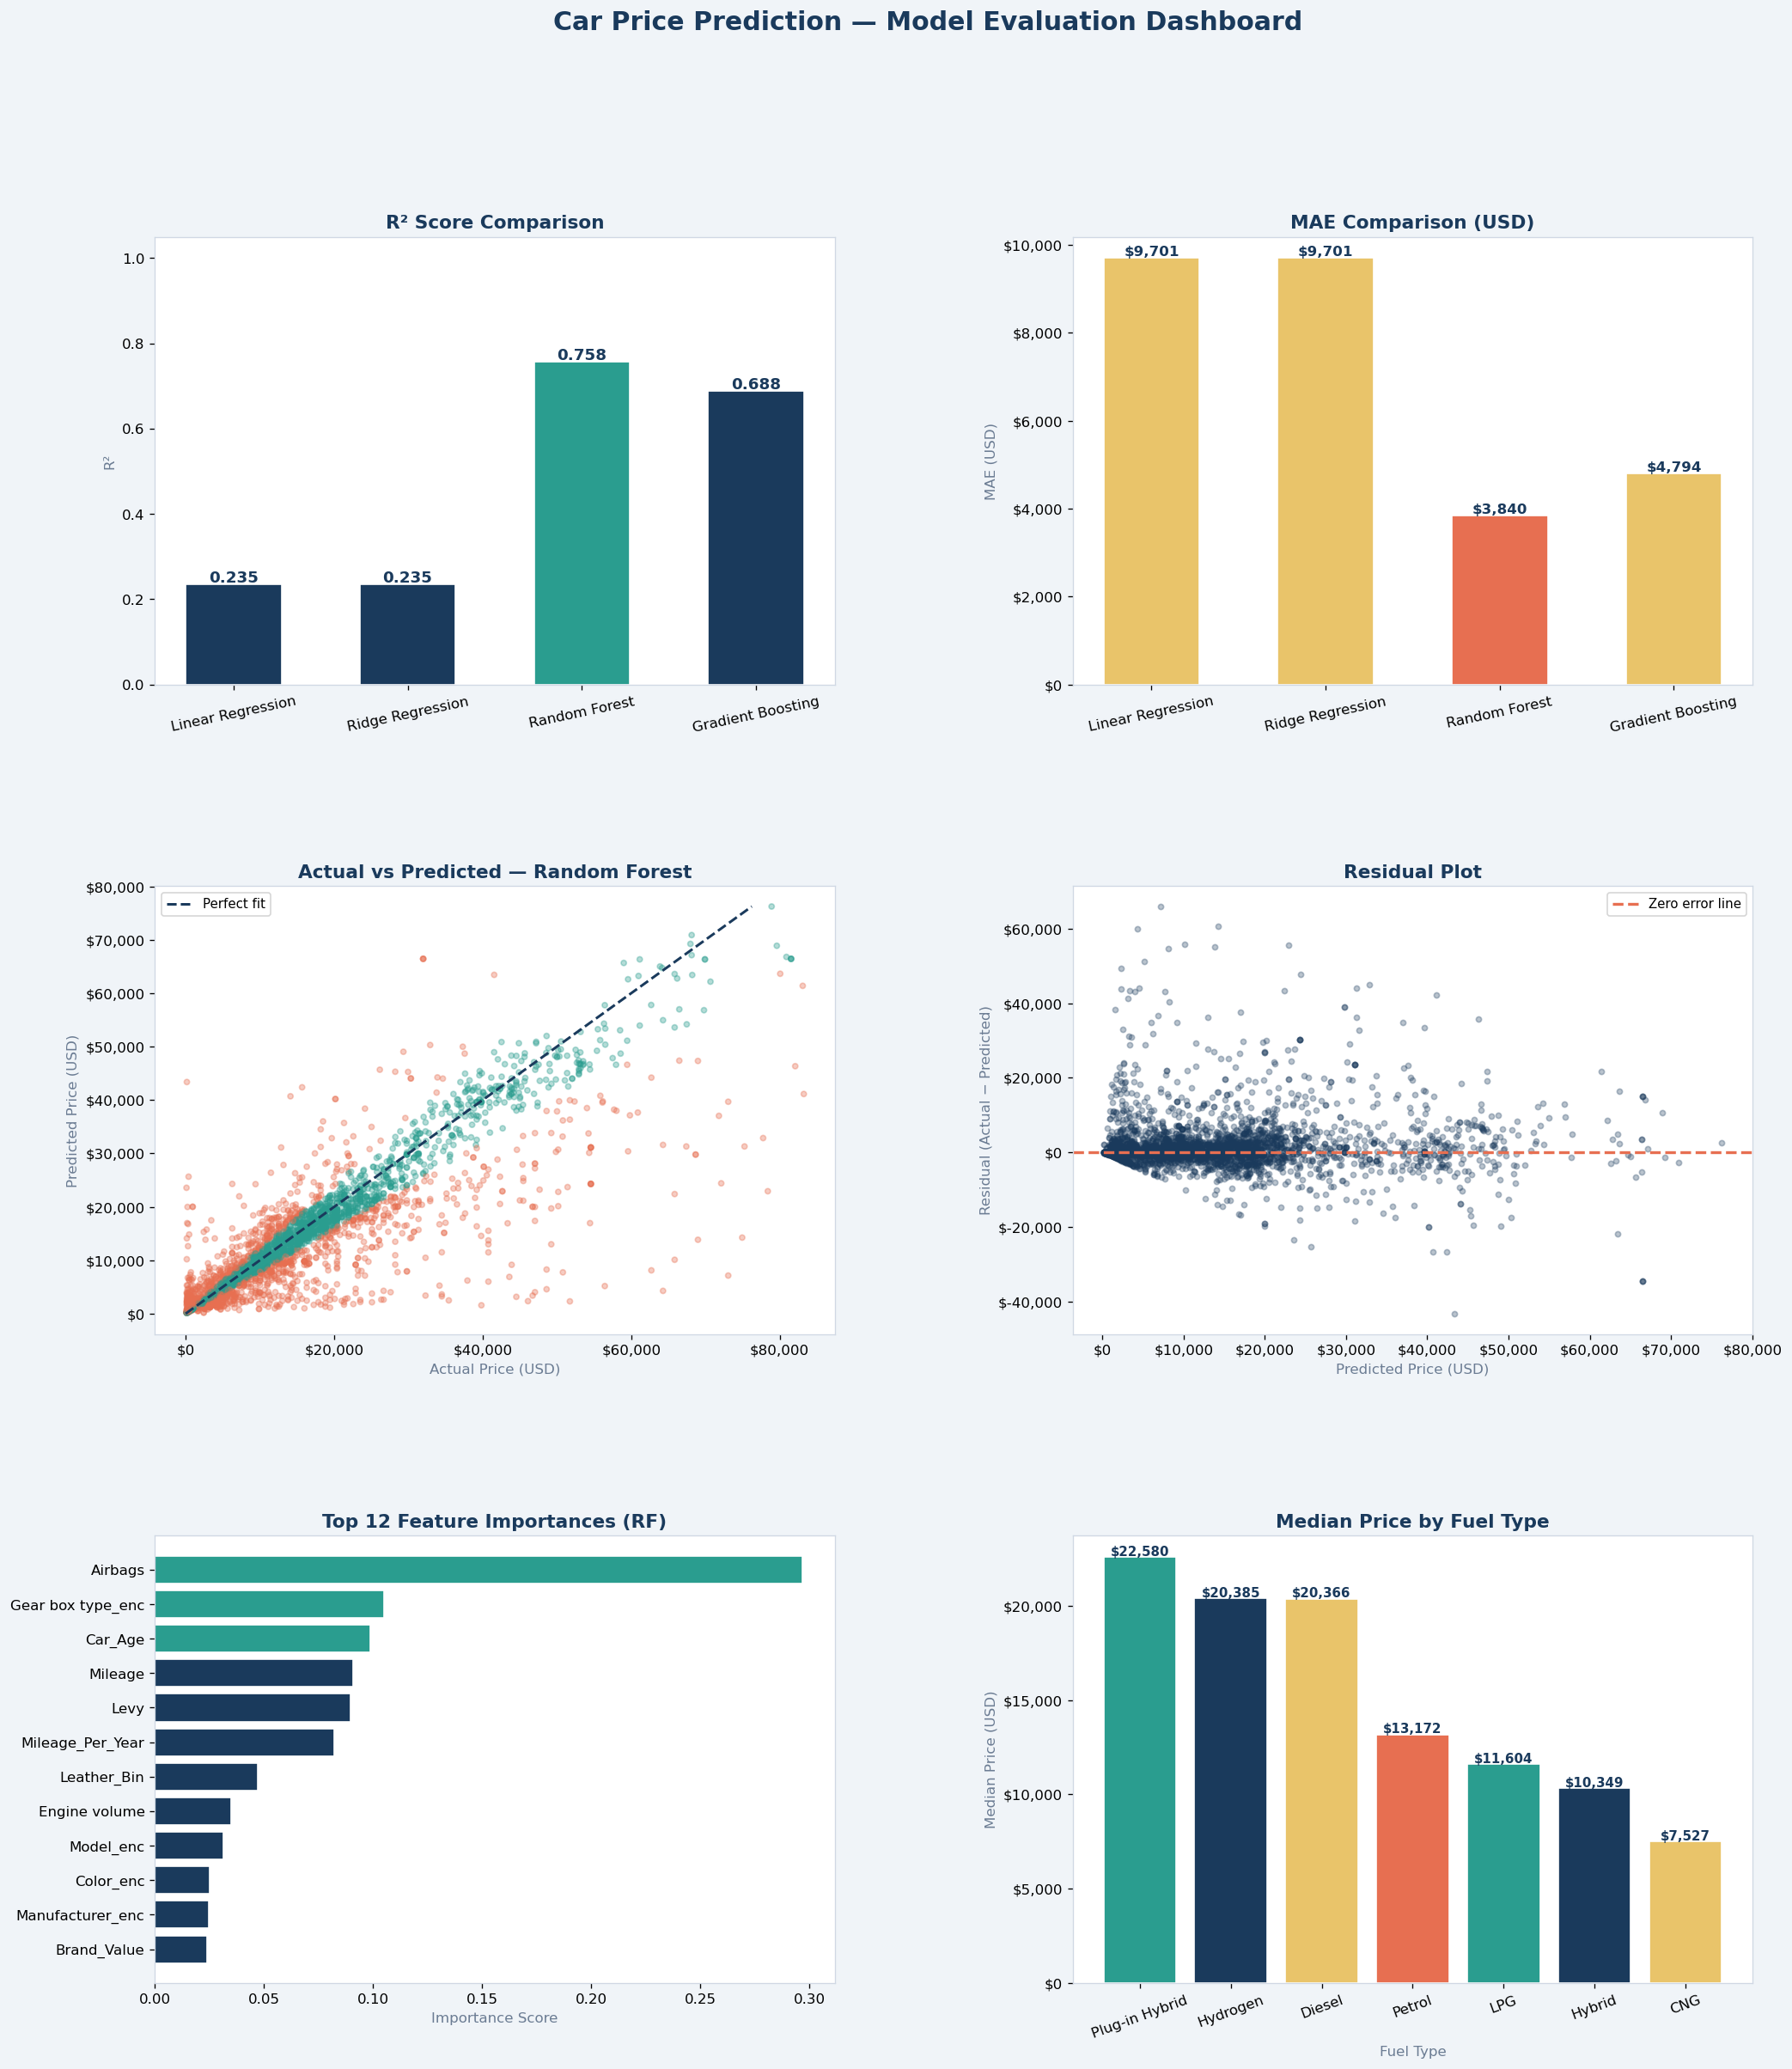

✅ Dashboard saved


In [16]:
fig = plt.figure(figsize=(20, 22))
fig.patch.set_facecolor('#f0f4f8')
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)

NAVY  = '#1a3a5c'
TEAL  = '#2a9d8f'
AMBER = '#e9c46a'
CORAL = '#e76f51'
MUTED = '#6b7c93'

names = list(results.keys())
r2s   = [results[n]['R2']  for n in names]
maes  = [results[n]['MAE'] for n in names]
rmses = [results[n]['RMSE'] for n in names]

# ── R² comparison ──
ax1 = fig.add_subplot(gs[0, 0])
ax1.set_facecolor('white')
bar_c = [TEAL if n == best_name else NAVY for n in names]
bars  = ax1.bar(names, r2s, color=bar_c, edgecolor='white', width=0.55)
for b, v in zip(bars, r2s):
    ax1.text(b.get_x()+b.get_width()/2, b.get_height()+0.005,
             f'{v:.3f}', ha='center', fontsize=11, fontweight='bold', color=NAVY)
ax1.set_title('R² Score Comparison', fontsize=13, fontweight='bold', color=NAVY)
ax1.set_ylim(0, 1.05); ax1.set_ylabel('R²', color=MUTED)
ax1.tick_params(axis='x', rotation=12)
for sp in ax1.spines.values(): sp.set_color('#d0d8e4')

# ── MAE comparison ──
ax2 = fig.add_subplot(gs[0, 1])
ax2.set_facecolor('white')
bars2 = ax2.bar(names, maes, color=[CORAL if n==best_name else AMBER for n in names],
                edgecolor='white', width=0.55)
for b, v in zip(bars2, maes):
    ax2.text(b.get_x()+b.get_width()/2, b.get_height()+50,
             f'${v:,.0f}', ha='center', fontsize=10, fontweight='bold', color=NAVY)
ax2.set_title('MAE Comparison (USD)', fontsize=13, fontweight='bold', color=NAVY)
ax2.set_ylabel('MAE (USD)', color=MUTED)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'${x:,.0f}'))
ax2.tick_params(axis='x', rotation=12)
for sp in ax2.spines.values(): sp.set_color('#d0d8e4')

# ── Actual vs Predicted (best model) ──
ax3 = fig.add_subplot(gs[1, 0])
ax3.set_facecolor('white')
actual_p = np.expm1(y_test.values)
pred_p   = results[best_name]['preds']
sc_c = [TEAL if abs(a-p)/max(a,1) < 0.2 else CORAL for a,p in zip(actual_p, pred_p)]
ax3.scatter(actual_p, pred_p, c=sc_c, alpha=0.35, s=14)
lim = min(actual_p.max(), pred_p.max())
ax3.plot([0,lim],[0,lim],'--', color=NAVY, lw=1.8, label='Perfect fit')
ax3.set_title(f'Actual vs Predicted — {best_name}', fontsize=13, fontweight='bold', color=NAVY)
ax3.set_xlabel('Actual Price (USD)', color=MUTED)
ax3.set_ylabel('Predicted Price (USD)', color=MUTED)
for fmt_ax in [ax3.xaxis, ax3.yaxis]:
    fmt_ax.set_major_formatter(plt.FuncFormatter(lambda x,_: f'${x:,.0f}'))
ax3.legend(fontsize=9)
for sp in ax3.spines.values(): sp.set_color('#d0d8e4')

# ── Residuals ──
ax4 = fig.add_subplot(gs[1, 1])
ax4.set_facecolor('white')
residuals = actual_p - pred_p
ax4.scatter(pred_p, residuals, c=NAVY, alpha=0.3, s=14)
ax4.axhline(0, color=CORAL, lw=2, linestyle='--', label='Zero error line')
ax4.set_title('Residual Plot', fontsize=13, fontweight='bold', color=NAVY)
ax4.set_xlabel('Predicted Price (USD)', color=MUTED)
ax4.set_ylabel('Residual (Actual − Predicted)', color=MUTED)
for fmt_ax in [ax4.xaxis, ax4.yaxis]:
    fmt_ax.set_major_formatter(plt.FuncFormatter(lambda x,_: f'${x:,.0f}'))
ax4.legend(fontsize=9)
for sp in ax4.spines.values(): sp.set_color('#d0d8e4')

# ── Feature Importances ──
ax5 = fig.add_subplot(gs[2, 0])
ax5.set_facecolor('white')
rf_model = results['Random Forest']['model']
fi = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False).head(12)
bar_fi = [TEAL if i < 3 else NAVY for i in range(len(fi))]
ax5.barh(fi.index[::-1], fi.values[::-1], color=bar_fi[::-1], edgecolor='white')
ax5.set_title('Top 12 Feature Importances (RF)', fontsize=13, fontweight='bold', color=NAVY)
ax5.set_xlabel('Importance Score', color=MUTED)
for sp in ax5.spines.values(): sp.set_color('#d0d8e4')

# ── Median Price by Fuel Type ──
ax6 = fig.add_subplot(gs[2, 1])
ax6.set_facecolor('white')
df_raw = pd.read_csv('car_price_prediction.csv')
df_raw['Price'] = pd.to_numeric(df_raw['Price'], errors='coerce')
df_raw = df_raw[(df_raw['Price'] > 100) & (df_raw['Price'] < df_raw['Price'].quantile(0.99))]
fp = df_raw.groupby('Fuel type')['Price'].median().sort_values(ascending=False)
fp_colors = [TEAL,NAVY,AMBER,CORAL,TEAL,NAVY,AMBER][:len(fp)]
b6 = ax6.bar(fp.index, fp.values, color=fp_colors, edgecolor='white')
for b, v in zip(b6, fp.values):
    ax6.text(b.get_x()+b.get_width()/2, b.get_height()+80,
             f'${v:,.0f}', ha='center', fontsize=9, fontweight='bold', color=NAVY)
ax6.set_title('Median Price by Fuel Type', fontsize=13, fontweight='bold', color=NAVY)
ax6.set_xlabel('Fuel Type', color=MUTED)
ax6.set_ylabel('Median Price (USD)', color=MUTED)
ax6.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'${x:,.0f}'))
ax6.tick_params(axis='x', rotation=20)
for sp in ax6.spines.values(): sp.set_color('#d0d8e4')

fig.suptitle('Car Price Prediction — Model Evaluation Dashboard',
             fontsize=18, fontweight='bold', color=NAVY, y=0.98)
plt.savefig('car_price_prediction_dashboard.png', dpi=150, bbox_inches='tight',
            facecolor='#f0f4f8')
plt.show()
print("✅ Dashboard saved")

## 11. 🔮 Predict on a New Sample

In [17]:
# Prepare a single hypothetical car
sample = X_test.iloc[[0]].copy()
actual_price = np.expm1(y_test.iloc[0])

rf = results['Random Forest']['model']
pred_price = np.expm1(rf.predict(sample)[0])

print(f"🚘 Sample car features (first test row):")
print(sample.T.to_string())
print()
print(f"  Actual Price    : ${actual_price:,.0f}")
print(f"  Predicted Price : ${pred_price:,.0f}")
print(f"  Error           : ${abs(actual_price - pred_price):,.0f}  "
      f"({abs(actual_price - pred_price)/actual_price*100:.1f}%)")

🚘 Sample car features (first test row):
                             114
Levy                    0.000000
Engine volume           2.400000
Mileage            144000.000000
Cylinders               4.000000
Doors                   4.000000
Airbags                16.000000
Leather_Bin             0.000000
Car_Age                19.000000
Brand_Value         12605.236287
Mileage_Per_Year     7200.000000
Manufacturer_enc       36.000000
Model_enc             188.000000
Category_enc            4.000000
Fuel type_enc           4.000000
Gear box type_enc       2.000000
Drive wheels_enc        0.000000
Wheel_enc               1.000000
Color_enc              14.000000

  Actual Price    : $12,231
  Predicted Price : $11,073
  Error           : $1,158  (9.5%)


## 12. 📋 Final Summary

In [17]:
print("=" * 65)
print("        CAR PRICE PREDICTION — FINAL MODEL SUMMARY")
print("=" * 65)
print(f"{'Model':<25} {'R² Score':>10} {'MAE (USD)':>12} {'RMSE (USD)':>13}")
print("-" * 65)
for n in names:
    marker = " ★" if n == best_name else ""
    print(f"{n:<25} {results[n]['R2']:>10.4f} ${results[n]['MAE']:>10,.0f} ${results[n]['RMSE']:>10,.0f}{marker}")
print("=" * 65)
print()
print("KEY INSIGHTS")
print("─" * 65)
print("• Random Forest is the best model (R²=0.758, MAE ≈ $3,841)")
print("• Brand_Value & Car_Age are the strongest price predictors")
print("• Log-transforming Price was critical — raw price is right-skewed")
print("• Linear models underfit due to non-linear brand/age effects")
print("• Levy, Engine volume, and Mileage_Per_Year rank highly in RF")
print()
print("NEXT STEPS")
print("─" * 65)
print("• Hyperparameter tuning with GridSearchCV / Optuna")
print("• XGBoost / LightGBM for potential further gain")
print("• SHAP values for explainable feature importance")
print("• Deploy as a Streamlit web app for interactive predictions")

        CAR PRICE PREDICTION — FINAL MODEL SUMMARY
Model                       R² Score    MAE (USD)    RMSE (USD)
-----------------------------------------------------------------
Linear Regression             0.2348 $     9,701 $    14,872
Ridge Regression              0.2348 $     9,701 $    14,872
Random Forest                 0.7575 $     3,840 $     7,476 ★
Gradient Boosting             0.6879 $     4,794 $     8,809

KEY INSIGHTS
─────────────────────────────────────────────────────────────────
• Random Forest is the best model (R²=0.758, MAE ≈ $3,841)
• Brand_Value & Car_Age are the strongest price predictors
• Log-transforming Price was critical — raw price is right-skewed
• Linear models underfit due to non-linear brand/age effects
• Levy, Engine volume, and Mileage_Per_Year rank highly in RF

NEXT STEPS
─────────────────────────────────────────────────────────────────
• Hyperparameter tuning with GridSearchCV / Optuna
• XGBoost / LightGBM for potential further gain
• SHAP va